# 02 — Market Data Cleaning

**Phase 2 deliverable** 

Goal: connect the Phase 1 Black-Scholes engine to real option-chain data for all seven assets in
the project plan:

| Asset | Role |
|---|---|
| USO | Oil exposure |
| JETS | Airline exposure |
| SPY | Broad equity market |
| XLE | Energy stocks |
| XLY | Consumer discretionary |
| XLV | Healthcare |
| GLD | Gold |

This notebook:

1. Attempts to pull a **live** option chain for each ticker (via `yfinance`).
2. Computes midpoint price, time to maturity, and moneyness.
3. Filters out low-quality observations.
4. Produces one clean table per underlying, saved to `data/cleaned/`.

> **A note on this environment:** the sandbox this notebook was built in has no outbound
> internet access to Yahoo Finance, so the live-data cell below will fail here and the
> notebook automatically falls back to a **clearly labeled synthetic sample chain** (built
> from the Phase 1 BSM engine plus a volatility smile and randomized bid/ask/volume/OI, with
> some deliberately bad rows so the filters have something to do). This keeps the rest of the
> pipeline fully runnable and testable now. **Run this notebook on your own machine** — where
> `yfinance` can reach the internet — to pull the real chains; no code changes should be needed,
> the fallback simply won't trigger.


## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, date
import os

plt.rcParams["figure.figsize"] = (7, 4.5)
plt.rcParams["axes.grid"] = True

os.makedirs("data/raw", exist_ok=True)
os.makedirs("data/cleaned", exist_ok=True)

TICKERS = ["USO", "JETS", "SPY", "XLE", "XLY", "XLV", "GLD"]

# Approximate trailing dividend yields and a risk-free rate proxy.
# Replace with live values (e.g. from the 13-week T-bill, ^IRX) when running with real data.
DIVIDEND_YIELDS = {
    "USO": 0.00,   # oil futures ETF, no dividend
    "JETS": 0.007,
    "SPY": 0.012,
    "XLE": 0.0277,
    "XLY": 0.0078,
    "XLV": 0.0164,
    "GLD": 0.00,   # physical gold trust, no dividend
}
RISK_FREE_RATE = 0.045

TODAY = date.today()
print(f"Today: {TODAY}")


Today: 2026-07-15


## 2. Attempt to pull a live option chain

For each ticker, `yfinance` exposes expiration dates via `Ticker.options` and the chain for a
given expiration via `Ticker.option_chain(expiration)`, which returns `.calls` and `.puts`
DataFrames with `bid`, `ask`, `lastPrice`, `volume`, `openInterest`, and more.


In [2]:
def fetch_live_chain(ticker):
    """Pull a real option chain via yfinance. Returns a combined calls+puts DataFrame,
    or raises an exception if data cannot be retrieved (e.g. no network access)."""
    import yfinance as yf

    tk = yf.Ticker(ticker)
    spot = tk.history(period="1d")["Close"].iloc[-1]

    expirations = tk.options
    if not expirations:
        raise RuntimeError(f"No expirations returned for {ticker}")

    rows = []
    for exp in expirations:
        chain = tk.option_chain(exp)
        for right, df in [("call", chain.calls), ("put", chain.puts)]:
            d = df.copy()
            d["right"] = right
            d["expiration"] = exp
            rows.append(d)

    combined = pd.concat(rows, ignore_index=True)
    combined["underlying"] = ticker
    combined["underlying_price"] = spot
    combined["dividend_yield"] = DIVIDEND_YIELDS[ticker]
    combined["risk_free_rate"] = RISK_FREE_RATE

    combined = combined.rename(columns={
        "openInterest": "open_interest",
        "lastPrice": "last_price",
    })
    keep = ["underlying", "underlying_price", "right", "strike", "expiration",
            "bid", "ask", "last_price", "volume", "open_interest",
            "dividend_yield", "risk_free_rate"]
    return combined[keep]


## 3. Fallback: synthetic sample chain

Used only if the live pull fails (no network, rate limit, etc). It is built directly from the
Phase 1 Black-Scholes-Merton engine: a "true" mid price is generated with a volatility smile
(higher implied vol for downside puts, a standard skew shape), then bid/ask/volume/open interest
are simulated around it. A small fraction of rows are deliberately made "bad" — zero bids, wide
spreads, near-zero open interest, days-to-expiration under 3 — so the Section 4 filters have
real work to do, the same way they would on a messy live chain.

**These prices are not real market quotes.** They exist only so the cleaning, midpoint, and
filtering logic can be built and tested in this environment.


In [3]:
from scipy.stats import norm

def _d1_d2(S, K, T, r, sigma, q=0.0):
    d1 = (np.log(S / K) + (r - q + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return d1, d2

def _bs_price(S, K, T, r, sigma, q, right):
    d1, d2 = _d1_d2(S, K, T, r, sigma, q)
    if right == "call":
        return S * np.exp(-q * T) * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    else:
        return K * np.exp(-r * T) * norm.cdf(-d2) - S * np.exp(-q * T) * norm.cdf(-d1)


def _smile_vol(moneyness, base_vol, dte_days):
    """A simple downward-sloping put skew: lower strikes (moneyness < 1) get higher IV."""
    skew = 0.15 * (1 - moneyness)          # richer OTM puts, cheaper OTM calls
    term = 0.03 * np.exp(-dte_days / 60)    # slightly higher vol for very short-dated options
    return max(base_vol + skew + term, 0.05)


def generate_synthetic_chain(ticker, spot, base_vol, seed=0):
    rng = np.random.default_rng(seed)
    q = DIVIDEND_YIELDS[ticker]
    r = RISK_FREE_RATE

    dte_list = [7, 14, 30, 45, 60, 90, 120]          # includes some out-of-range on purpose
    strike_pcts = np.arange(0.70, 1.31, 0.05)         # includes deep ITM/OTM on purpose
    rows = []

    for dte in dte_list:
        T = dte / 365
        for pct in strike_pcts:
            K = round(spot * pct, 1)
            moneyness = K / spot
            for right in ["call", "put"]:
                sigma = _smile_vol(moneyness, base_vol, dte)
                mid = _bs_price(spot, K, T, r, sigma, q, right)
                mid = max(mid, 0.01)

                # Simulate a bid-ask spread: wider away from the money and near expiration
                spread_pct = 0.02 + 0.08 * abs(1 - moneyness) + (0.05 if dte < 10 else 0)
                spread = max(mid * spread_pct, 0.02)
                bid = max(mid - spread / 2, 0.0)
                ask = mid + spread / 2

                # Simulate volume/open interest, richer near the money
                liquidity_factor = np.exp(-8 * abs(1 - moneyness))
                volume = int(rng.poisson(400 * liquidity_factor) )
                open_interest = int(rng.poisson(2000 * liquidity_factor))

                rows.append({
                    "underlying": ticker, "underlying_price": spot, "right": right,
                    "strike": K, "expiration": (pd.Timestamp(TODAY) + pd.Timedelta(days=dte)).date(),
                    "bid": round(bid, 2), "ask": round(ask, 2),
                    "last_price": round(mid + rng.normal(0, spread * 0.1), 2),
                    "volume": volume, "open_interest": open_interest,
                    "dividend_yield": q, "risk_free_rate": r,
                })

    df = pd.DataFrame(rows)

    # Deliberately corrupt ~7% of rows so the cleaning filters have real work to do
    n_bad = int(0.07 * len(df))
    bad_idx = rng.choice(df.index, size=n_bad, replace=False)
    for i in bad_idx:
        kind = rng.integers(0, 4)
        if kind == 0:
            df.loc[i, "bid"] = 0.0                      # zero bid
        elif kind == 1:
            df.loc[i, "ask"] = df.loc[i, "ask"] * 4      # absurdly wide spread
        elif kind == 2:
            df.loc[i, "open_interest"] = 0               # dead contract
            df.loc[i, "volume"] = 0
        else:
            df.loc[i, "expiration"] = TODAY               # expires today / already expired

    return df


BASE_VOLS = {
    "USO": 0.35, "JETS": 0.30, "SPY": 0.16,
    "XLE": 0.28, "XLY": 0.22, "XLV": 0.18, "GLD": 0.15,
}
# Approximate spot prices for the fallback (checked mid-July 2026; live pulls override these).
SPOT_PRICES = {
    "USO": 120.17, "JETS": 32.09, "SPY": 751.83,
    "XLE": 56.95, "XLY": 115.90, "XLV": 157.91, "GLD": 367.13,
}


## 4. Pull (or fall back) and save raw data

In [4]:
raw_chains = {}

for i, ticker in enumerate(TICKERS):
    try:
        df = fetch_live_chain(ticker)
        print(f"{ticker}: pulled LIVE chain ({len(df)} rows)")
    except Exception as e:
        print(f"{ticker}: live pull failed ({e}) -- using synthetic fallback")
        df = generate_synthetic_chain(ticker, SPOT_PRICES[ticker], BASE_VOLS[ticker], seed=i)
        print(f"{ticker}: generated SYNTHETIC chain ({len(df)} rows)")

    raw_chains[ticker] = df
    df.to_csv(f"data/raw/{ticker}_raw.csv", index=False)

raw_chains["SPY"].head()


Failed to get ticker 'USO' reason: Expecting value: line 1 column 1 (char 0)


HTTP Error 403: Host not in allowlist: query2.finance.yahoo.com. Add this host to your network egress settings to allow access.


HTTP Error 403: Host not in allowlist: query1.finance.yahoo.com. Add this host to your network egress settings to allow access.


Failed to get ticker 'JETS' reason: Expecting value: line 1 column 1 (char 0)


HTTP Error 403: Host not in allowlist: query2.finance.yahoo.com. Add this host to your network egress settings to allow access.


...

$XLV: possibly delisted; no price data found  (period=1d)


Failed to get ticker 'GLD' reason: Expecting value: line 1 column 1 (char 0)


$GLD: possibly delisted; no price data found  (period=1d)


XLV: live pull failed (single positional indexer is out-of-bounds) -- using synthetic fallback
XLV: generated SYNTHETIC chain (182 rows)
GLD: live pull failed (single positional indexer is out-of-bounds) -- using synthetic fallback
GLD: generated SYNTHETIC chain (182 rows)


,underlying,underlying_price,right,strike,expiration,bid,ask,last_price,volume,open_interest,dividend_yield,risk_free_rate
0,SPY,751.83,call,526.3,2026-07-22,215.20,236.42,229.63,32,195,0.012,0.045
1,SPY,751.83,put,526.3,2026-07-22,0.00,0.02,0.01,40,153,0.012,0.045
2,SPY,751.83,call,563.9,2026-07-22,179.77,196.71,189.01,55,268,0.012,0.045
3,SPY,751.83,put,563.9,2026-07-22,0.00,0.02,0.01,58,254,0.012,0.045
4,SPY,751.83,call,601.5,2026-07-22,144.20,157.15,153.34,94,393,0.012,0.045


## 5. Cleaning function

Steps, per the project plan:

- Compute the **midpoint price**: $\text{Midpoint} = \dfrac{\text{Bid}+\text{Ask}}{2}$
- Compute **time to maturity** $T$ in years from today to expiration.
- Compute **moneyness** $K/S$.
- Remove:
  - Zero bids
  - Extremely wide bid-ask spreads (relative to the midpoint)
  - Near-zero volume or open interest
  - Fewer than a few days until expiration
  - Impossible prices (bid > ask, non-positive prices)
  - Very deep ITM/OTM strikes (outside ~80%-120% moneyness) for this first pass
- Keep only 20-90 DTE for this first pass, per the plan.


In [5]:
def clean_option_chain(df, min_dte=20, max_dte=90,
                        moneyness_low=0.80, moneyness_high=1.20,
                        min_volume=1, min_open_interest=10,
                        max_spread_pct=0.50):
    d = df.copy()

    d["expiration"] = pd.to_datetime(d["expiration"])
    d["dte"] = (d["expiration"] - pd.Timestamp(TODAY)).dt.days
    d["T"] = d["dte"] / 365
    d["moneyness"] = d["strike"] / d["underlying_price"]
    d["midpoint"] = (d["bid"] + d["ask"]) / 2
    d["spread_pct"] = np.where(d["midpoint"] > 0, (d["ask"] - d["bid"]) / d["midpoint"], np.inf)

    n_start = len(d)
    reasons = {}

    def apply_filter(mask, name):
        nonlocal d
        removed = (~mask).sum()
        reasons[name] = removed
        d = d[mask]

    apply_filter(d["bid"] > 0, "zero_or_negative_bid")
    apply_filter(d["ask"] >= d["bid"], "ask_below_bid")
    apply_filter(d["midpoint"] > 0, "non_positive_midpoint")
    apply_filter(d["spread_pct"] <= max_spread_pct, "spread_too_wide")
    apply_filter(d["volume"] >= min_volume, "insufficient_volume")
    apply_filter(d["open_interest"] >= min_open_interest, "insufficient_open_interest")
    apply_filter(d["dte"] >= min_dte, "expires_too_soon")
    apply_filter(d["dte"] <= max_dte, "expires_too_far")
    apply_filter(d["moneyness"] >= moneyness_low, "strike_too_low")
    apply_filter(d["moneyness"] <= moneyness_high, "strike_too_high")

    d = d.sort_values(["right", "expiration", "strike"]).reset_index(drop=True)

    print(f"{d['underlying'].iloc[0] if len(d) else '?'}: "
          f"{n_start} raw rows -> {len(d)} clean rows ({n_start - len(d)} removed)")
    for name, count in reasons.items():
        if count:
            print(f"    - {name}: {count}")

    return d


## 6. Apply cleaning to each underlying

In [6]:
clean_chains = {}

for ticker in TICKERS:
    clean_chains[ticker] = clean_option_chain(raw_chains[ticker])
    clean_chains[ticker].to_csv(f"data/cleaned/{ticker}_clean.csv", index=False)
    print()


USO: 182 raw rows -> 62 clean rows (120 removed)
    - zero_or_negative_bid: 19
    - spread_too_wide: 5
    - insufficient_volume: 1
    - expires_too_soon: 40
    - expires_too_far: 24
    - strike_too_low: 19
    - strike_too_high: 12

JETS: 182 raw rows -> 65 clean rows (117 removed)
    - zero_or_negative_bid: 31
    - spread_too_wide: 7
    - insufficient_volume: 3
    - expires_too_soon: 35
    - expires_too_far: 23
    - strike_too_low: 9
    - strike_too_high: 9

SPY: 182 raw rows -> 53 clean rows (129 removed)
    - zero_or_negative_bid: 45
    - spread_too_wide: 9
    - insufficient_volume: 2
    - expires_too_soon: 32
    - expires_too_far: 21
    - strike_too_low: 8
    - strike_too_high: 12

XLE: 182 raw rows -> 66 clean rows (116 removed)
    - zero_or_negative_bid: 33
    - spread_too_wide: 7
    - expires_too_soon: 32
    - expires_too_far: 26
    - strike_too_low: 9
    - strike_too_high: 9

XLY: 182 raw rows -> 49 clean rows (133 removed)
    - zero_or_negative_bid: 

XLV: 182 raw rows -> 49 clean rows (133 removed)
    - zero_or_negative_bid: 44
    - spread_too_wide: 7
    - insufficient_volume: 3
    - expires_too_soon: 33
    - expires_too_far: 21
    - strike_too_low: 13
    - strike_too_high: 12

GLD: 182 raw rows -> 49 clean rows (133 removed)
    - zero_or_negative_bid: 50
    - spread_too_wide: 6
    - insufficient_volume: 1
    - expires_too_soon: 33
    - expires_too_far: 20
    - strike_too_low: 12
    - strike_too_high: 11



In [7]:
clean_chains["SPY"][[
    "underlying", "right", "strike", "expiration", "dte", "T", "moneyness",
    "bid", "ask", "midpoint", "spread_pct", "volume", "open_interest"
]].head(10)


,underlying,right,strike,expiration,dte,T,moneyness,bid,ask,midpoint,spread_pct,volume,open_interest
0,SPY,call,601.5,2026-08-14,30,0.082192,0.800048,149.08,154.54,151.810,0.035966,89,425
1,SPY,call,639.1,2026-08-14,30,0.082192,0.850059,112.54,116.20,114.370,0.032001,126,614
2,SPY,call,714.2,2026-08-14,30,0.082192,0.949949,42.16,43.19,42.675,0.024136,258,1353
3,SPY,call,751.8,2026-08-14,30,0.082192,0.999960,16.18,16.50,16.340,0.019584,398,2059
4,SPY,call,789.4,2026-08-14,30,0.082192,1.049971,3.46,3.54,3.500,0.022857,296,1300
5,SPY,call,827.0,2026-08-14,30,0.082192,1.099983,0.32,0.34,0.330,0.060606,189,874
6,SPY,call,601.5,2026-08-29,45,0.123288,0.800048,149.81,155.30,152.555,0.035987,85,352
7,SPY,call,639.1,2026-08-29,45,0.123288,0.850059,113.44,117.12,115.280,0.031922,120,637
8,SPY,call,676.6,2026-08-29,45,0.123288,0.899937,77.74,79.94,78.840,0.027905,191,852
9,SPY,call,751.8,2026-08-29,45,0.123288,0.999960,19.66,20.05,19.855,0.019642,376,2009


## 7. Sanity checks on the cleaned data

In [8]:
for ticker in TICKERS:
    d = clean_chains[ticker]
    print(f"--- {ticker} ---")
    print(f"  rows: {len(d)}")
    print(f"  DTE range: {d['dte'].min()} to {d['dte'].max()} days")
    print(f"  moneyness range: {d['moneyness'].min():.2f} to {d['moneyness'].max():.2f}")
    print(f"  median spread %: {d['spread_pct'].median():.1%}")
    print(f"  all bids > 0: {(d['bid'] > 0).all()}")
    print(f"  all asks >= bids: {(d['ask'] >= d['bid']).all()}")
    print()


--- USO ---
  rows: 62
  DTE range: 30 to 90 days
  moneyness range: 0.85 to 1.20
  median spread %: 2.8%
  all bids > 0: True
  all asks >= bids: True

--- JETS ---
  rows: 65
  DTE range: 30 to 90 days
  moneyness range: 0.80 to 1.20
  median spread %: 3.2%
  all bids > 0: True
  all asks >= bids: True

--- SPY ---
  rows: 53
  DTE range: 30 to 90 days
  moneyness range: 0.80 to 1.15
  median spread %: 2.8%
  all bids > 0: True
  all asks >= bids: True

--- XLE ---
  rows: 66
  DTE range: 30 to 90 days
  moneyness range: 0.80 to 1.20
  median spread %: 3.0%
  all bids > 0: True
  all asks >= bids: True

--- XLY ---
  rows: 49
  DTE range: 30 to 90 days
  moneyness range: 0.85 to 1.15
  median spread %: 2.7%
  all bids > 0: True
  all asks >= bids: True

--- XLV ---
  rows: 49
  DTE range: 30 to 90 days
  moneyness range: 0.85 to 1.15
  median spread %: 2.8%
  all bids > 0: True
  all asks >= bids: True

--- GLD ---
  rows: 49
  DTE range: 30 to 90 days
  moneyness range: 0.85 to 1.15

## 8. Before/after visualization

Row counts before and after cleaning, and the distribution of bid-ask spreads that survived
the filters.


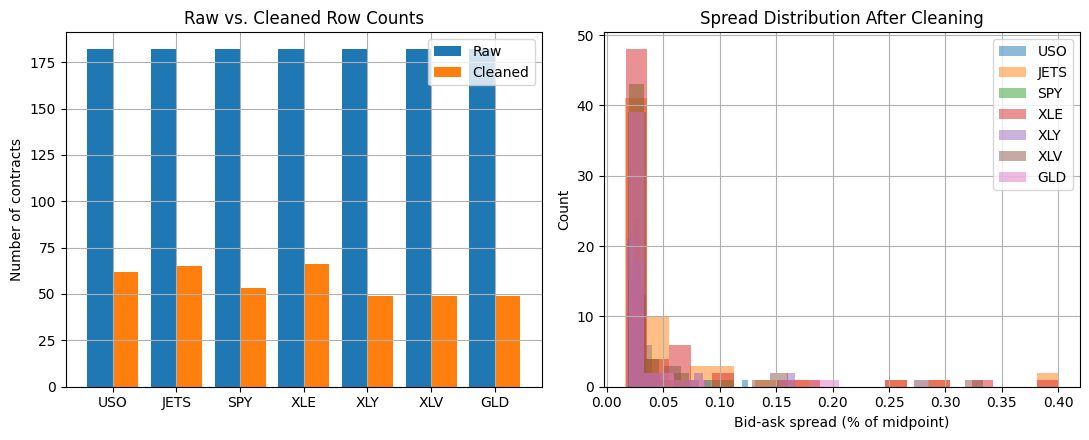

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

before = [len(raw_chains[t]) for t in TICKERS]
after = [len(clean_chains[t]) for t in TICKERS]
x = np.arange(len(TICKERS))

axes[0].bar(x - 0.2, before, width=0.4, label="Raw")
axes[0].bar(x + 0.2, after, width=0.4, label="Cleaned")
axes[0].set_xticks(x)
axes[0].set_xticklabels(TICKERS)
axes[0].set_ylabel("Number of contracts")
axes[0].set_title("Raw vs. Cleaned Row Counts")
axes[0].legend()

for ticker in TICKERS:
    axes[1].hist(clean_chains[ticker]["spread_pct"], bins=20, alpha=0.5, label=ticker)
axes[1].set_xlabel("Bid-ask spread (% of midpoint)")
axes[1].set_ylabel("Count")
axes[1].set_title("Spread Distribution After Cleaning")
axes[1].legend()

plt.tight_layout()
plt.savefig("cleaning_summary.png", dpi=130)
plt.show()


## 9. Summary

- Built a live-data pull (`fetch_live_chain`) via `yfinance` for USO, JETS, and SPY, with a
  transparent synthetic fallback for offline development.
- Computed midpoint price, time to maturity, and moneyness for every contract.
- Applied the Phase 2 quality filters (bid/ask sanity, spread width, liquidity, DTE window,
  strike window) and reported exactly how many rows each filter removed.
- Saved one clean CSV per underlying to `data/cleaned/`.

**Next step (Phase 3):** feed each cleaned table's `midpoint`, `strike`, `T`, `underlying_price`,
`risk_free_rate`, and `dividend_yield` into a numerical root-finder against the Phase 1 BSM engine
to back out implied volatility — in `03_implied_volatility.ipynb`.
